In [1]:
print("RITHANYA.G 24BAD132")
print("LSTM Sentiment Analysis")

RITHANYA.G 24BAD132
LSTM Sentiment Analysis


PART-A

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully")

TensorFlow version: 2.20.0
Libraries imported successfully


In [3]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("First review sequence:", x_train[0][:20])
print("First review label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First review sequence: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First review label: 1


Training Positive reviews: 12500
Training Negative reviews: 12500
Testing Positive reviews: 12500
Testing Negative reviews: 12500


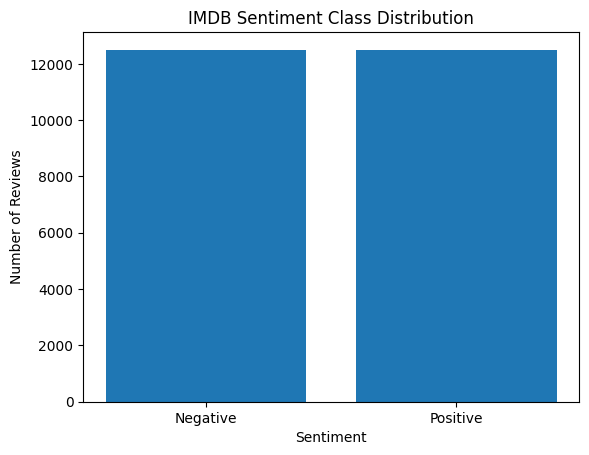

In [4]:
print("Training Positive reviews:", np.sum(y_train == 1))
print("Training Negative reviews:", np.sum(y_train == 0))
print("Testing Positive reviews:", np.sum(y_test == 1))
print("Testing Negative reviews:", np.sum(y_test == 0))

plt.bar(["Negative", "Positive"],
        [np.sum(y_train == 0), np.sum(y_train == 1)])

plt.title("IMDB Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [5]:
train_lengths = [len(review) for review in x_train]

print("Minimum review length:", min(train_lengths))
print("Maximum review length:", max(train_lengths))
print("Average review length:", np.mean(train_lengths))

Minimum review length: 11
Maximum review length: 2494
Average review length: 238.71364


In [6]:
max_length = 200

x_train_pad = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test_pad = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("RITHANYA.G 24BAD132")
print("Training data shape:", x_train_pad.shape)
print("Testing data shape:", x_test_pad.shape)
print("First padded sequence:", x_train_pad[0])

RITHANYA.G 24BAD132
Training data shape: (25000, 200)
Testing data shape: (25000, 200)
First padded sequence: [   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   

In [7]:
validation_size = 5000

x_val = x_train_pad[:validation_size]
y_val = y_train[:validation_size]

x_train_final = x_train_pad[validation_size:]
y_train_final = y_train[validation_size:]
print("Training data:", x_train_final.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test_pad.shape)

Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)


PART-B

In [8]:
embedding_dim = 128
print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)

Vocabulary size: 10000
Embedding dimension: 128


In [9]:
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_length
)
print("Embedding layer created successfully")

Embedding layer created successfully


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
sample_input = x_train_final[:1]

sample_embedding = embedding_layer(sample_input)
print("Input shape:", sample_input.shape)
print("Embedding shape:", sample_embedding.shape)

Input shape: (1, 200)
Embedding shape: (1, 200, 128)


PART-C

In [11]:
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    ),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

print("RITHANYA.G 24BAD132")
model.summary()

RITHANYA.G 24BAD132


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("RITHANYA.G 24BAD132")
print("Model compiled successfully")

RITHANYA.G 24BAD132
Model compiled successfully


PART-D

In [13]:


history = model.fit(
    x_train_final,
    y_train_final,
    epochs=5,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.5368 - loss: 0.6886 - val_accuracy: 0.6122 - val_loss: 0.6413
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 67s 428ms/step - accuracy: 0.6240 - loss: 0.6244 - val_accuracy: 0.6098 - val_loss: 0.6663
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 430ms/step - accuracy: 0.7457 - loss: 0.5070 - val_accuracy: 0.7842 - val_loss: 0.5038
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 447ms/step - accuracy: 0.8207 - loss: 0.4322 - val_accuracy: 0.7660 - val_loss: 0.5675
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 473ms/step - accuracy: 0.8839 - loss: 0.3102 - val_accuracy: 0.8496 - val_loss: 0.4060


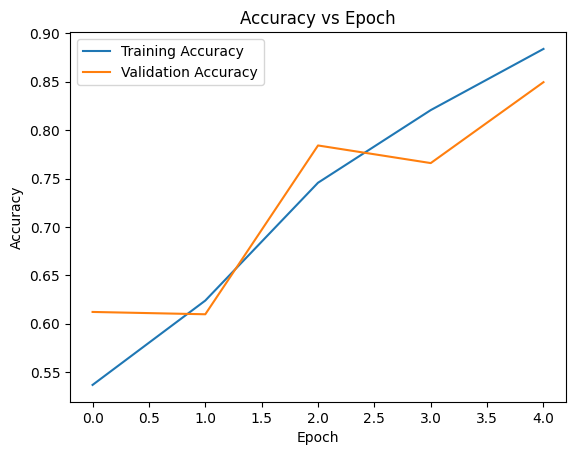

In [14]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

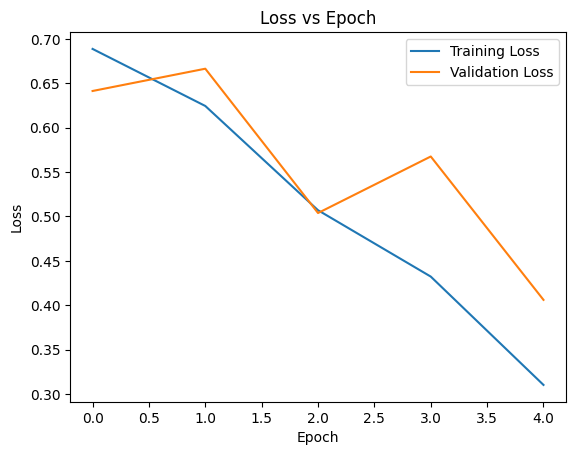

In [15]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(
    x_test_pad,
    y_test,
    verbose=0
)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.43589285016059875
Test Accuracy: 0.8343999981880188


In [17]:
y_pred_probability = model.predict(x_test_pad)

y_pred = (y_pred_probability >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("RITHANYA.G 24BAD132")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step
RITHANYA.G 24BAD132
Accuracy : 0.8344
Precision: 0.8562297596727458
Recall   : 0.80376
F1-score : 0.8291656350581827


RITHANYA.G 24BAD132
Confusion Matrix:
[[10813  1687]
 [ 2453 10047]]


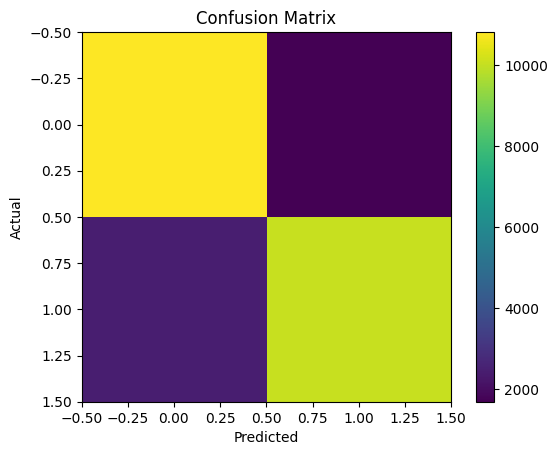

In [18]:
cm = confusion_matrix(y_test, y_pred)

print("RITHANYA.G 24BAD132")
print("Confusion Matrix:")
print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [19]:
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []

    for word in words:
        index = word_index.get(word, 2)
        if index < vocab_size:
            encoded.append(index + 3)
        else:
            encoded.append(2)

    return pad_sequences([encoded], maxlen=max_length, padding="post", truncating="post")

sample_reviews = [
    "This movie was excellent and I really enjoyed it",
    "This movie was terrible and I hated it"
]

print("RITHANYA.G 24BAD132")

for review in sample_reviews:
    encoded_review = encode_review(review)
    prediction = model.predict(encoded_review, verbose=0)[0][0]

    if prediction >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("\nReview:", review)
    print("Predicted Sentiment:", sentiment)
    print("Prediction Score:", prediction)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
RITHANYA.G 24BAD132

Review: This movie was excellent and I really enjoyed it
Predicted Sentiment: Positive
Prediction Score: 0.92920524

Review: This movie was terrible and I hated it
Predicted Sentiment: Negative
Prediction Score: 0.1717963
